In [135]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, SGDRegressor

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [136]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y  = 0.8x^2 + 0.9x + 2 + random_noise

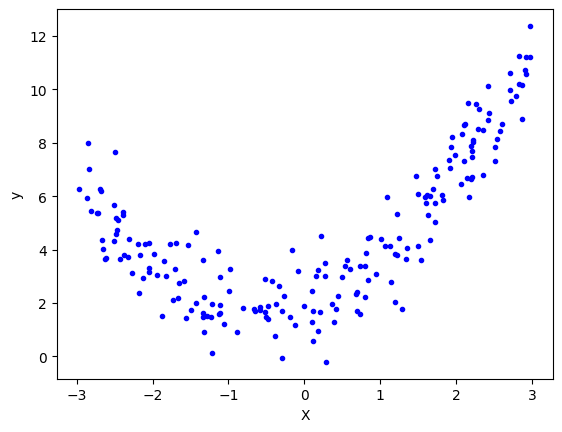

In [137]:
plt.plot(X, y, 'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [138]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [139]:
# Applying Linear Regression
lr = LinearRegression()

In [140]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [141]:
y_pred = lr.predict(X_test)
r2_score(y_test, y_pred)

0.21163887069044385

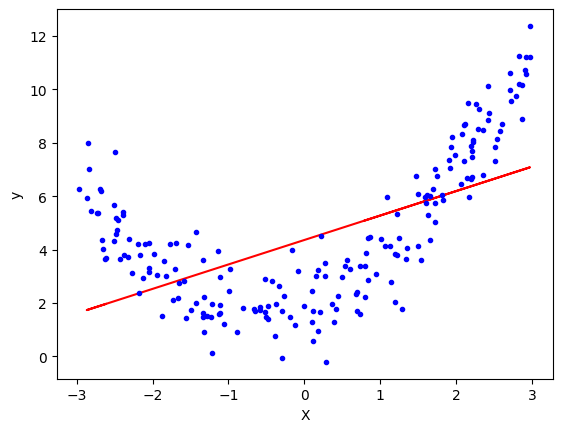

In [142]:
plt.plot(X_train, lr.predict(X_train), color='r')
plt.plot(X, y, "b.")
plt.xlabel('X')
plt.ylabel('y')
plt.show()

# Applying Polynomial Linear Regression

In [143]:
# degree 2
poly = PolynomialFeatures(degree=2, include_bias=True) # include_bias removes the bias term (intercept) from the polynomial features, 
                                                        # which is useful when you want to avoid multicollinearity and improve model interpretability.

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [144]:
print(X_train[0])
print(X_train_trans[0])

[0.79836435]
[1.         0.79836435 0.63738564]


In [145]:
# include_bias parameter

In [146]:
lr = LinearRegression()
lr.fit(X_train_trans, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [147]:
y_pred = lr.predict(X_test_trans)

In [148]:
r2_score(y_test, y_pred)

0.8480609615047046

In [149]:
print(lr.coef_)
print(lr.intercept_)

[[0.        0.8610994 0.7697653]]
[2.00217868]


In [150]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

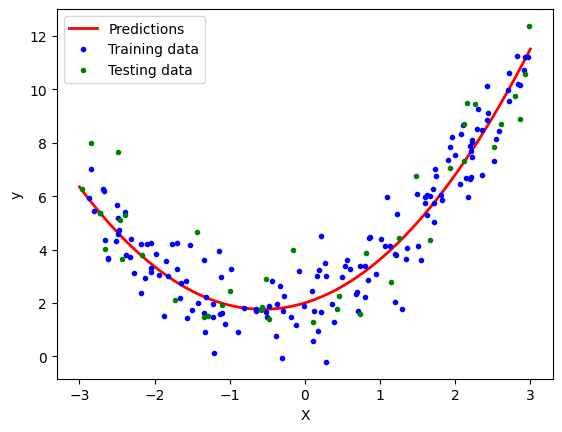

In [151]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.", label="Training data")
plt.plot(X_test, y_test, "g.", label="Testing data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [152]:
def polynomial_regression(degree):
    X_new = np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)
    
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
        ("poly_features", polybig_features),
        ("std_scaler", std_scaler),
        ("lin_reg", lin_reg)
    ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig, 'r', label='Degree' + str(degree), linewidth=2)
    
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc='upper left')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.axis([-3, 3, 0, 10])
    plt.show()

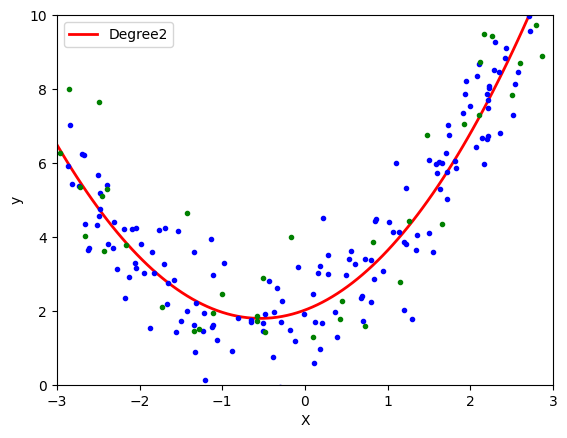

In [153]:
polynomial_regression(2) # Best degree would be 2 as the original data was generated using a quadratic function
# In real life dataset we will not know the underlying degree of the polynomial, so we will have to try 
# different degrees and use cross-validation to find the best degree for our model

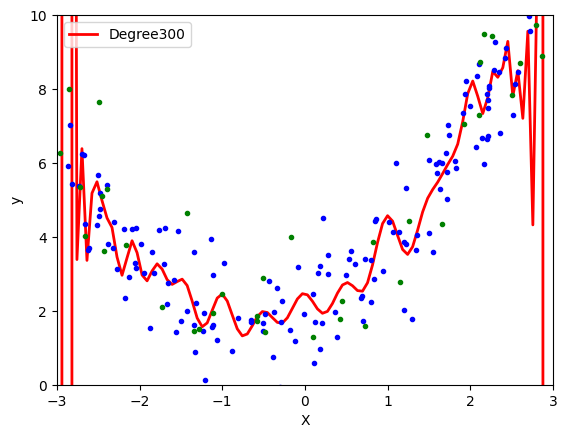

In [154]:
polynomial_regression(300) # Make sure you have enough data points to avoid overfitting when using a high degree polynomial.
# Make sure to adjust the degree based on the complexity of your data and the amount of noise present.

# Multiple Polynomial Regression

In [155]:
# 3D Polynomial Regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2 + random_noise

In [156]:
import plotly.express as px
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel(), color=z.ravel())

fig.show()

In [157]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input, y_input)

final = np.vstack((xGrid.ravel().reshape(1,100), yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [158]:
import plotly.graph_objects as go

fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel(), color=z.ravel())

fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_final))

fig.show()

In [159]:
X_multi = np.array([x, y]).reshape(100,2)
X_multi.shape

(100, 2)

In [176]:
poly = PolynomialFeatures(degree=6)
X_multi_trans = poly.fit_transform(X_multi)

In [177]:
print("Input", poly.n_features_in_)
print("Output", poly.n_output_features_)
print("Powers\n", poly.powers_)

Input 2
Output 28
Powers
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]
 [3 0]
 [2 1]
 [1 2]
 [0 3]
 [4 0]
 [3 1]
 [2 2]
 [1 3]
 [0 4]
 [5 0]
 [4 1]
 [3 2]
 [2 3]
 [1 4]
 [0 5]
 [6 0]
 [5 1]
 [4 2]
 [3 3]
 [2 4]
 [1 5]
 [0 6]]


In [178]:
X_multi_trans.shape

(100, 28)

In [179]:
lr = LinearRegression()
lr.fit(X_multi_trans, z)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [180]:
X_test_multi = poly.transform(final)

In [181]:
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [182]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_final))

fig.update_layout(scene=dict(zaxis = dict(range=[0, 35]))) 

fig.show()